## *Semana 3: Fundamentos estadísticos y optimización*

## 4.2. Explorando el problema: ¿qué infuye en la matrícula de cada semestre?

In [1]:
import numpy as np #importa la libreria NumPy para calculos numericos 
import pandas as pd #Importa pandas para manipular una estructura de datos
import matplotlib.pyplot as plt #Importa PyPlot de Matplotlib para la creación de gráficos y visualizaciones
from sklearn.linear_model import LinearRegression #Importa la clase de Regresión Lineal

matricula = pd.read_csv("matricula_sistemas.csv") #Lee el archivo CSV y carga el contenido
matricula.describe() #Calcula estadísticas descriptivas generales de todas las columnas numericas

,num_postulantes,becas_otorgadas,tasa_desercion_anterior,campania_difusion,num_matriculados
count,24.000000,24.000000,24.000000,24.000000,24.000000
mean,231.125000,18.250000,0.129917,0.500000,137.083333
std,41.277757,6.917212,0.021055,0.510754,34.122435
min,146.000000,8.000000,0.096000,0.000000,75.000000
25%,200.250000,12.750000,0.110750,0.000000,111.500000
50%,222.500000,17.500000,0.127500,0.500000,137.000000
75%,261.250000,24.250000,0.150250,1.000000,161.500000
max,311.000000,30.000000,0.167000,1.000000,198.000000


# Parte B ¿Cuántos alumnos se matriculan en promedio? ¿qué tan dispersa es esa cifra de un semestre a otro? Calcular los estadísticos descriptivos de num_matriculados:

In [3]:
col = matricula["num_matriculados"] #Selecciona la columna de la variable objetivo
print("Media:", col.mean()) #Calcula e imprime la media aritmética (promedio de matriculados por semestre)
print("Mediana:", col.median()) #Calcula e imprime la mediana (el valor central al ordenar los datos)
print("Moda:", col.mode().tolist()) #Encuentra el valor o valores que más se repiten y los convierte en una lista
print("Rango:", col.max() - col.min()) #Calcula la diferencia entre el valor máximo y el valor mínimo
print("Varianza:", col.var()) #Calcula la varianza muestral (grado de dispersión al cuadrado)
print("Desviacion estandar:", col.std()) #Calcula la desviación estándar muestral (dispersión en la misma unidad que los datos)

Media: 137.08333333333334
Mediana: 137.0
Moda: [120, 137, 160]
Rango: 123
Varianza: 1164.340579710145
Desviacion estandar: 34.12243513745971


# Parte C: Calcular la correlación de cada variable contra num_matriculados, para decidir cuáles conviene usar para predecirla::

In [4]:
matricula.corr(numeric_only=True)["num_matriculados"] #Calcula la matriz de correlación de Pearson entre todas las variables numéricas del dataset
#con ["num_matriculados"] filtramos el resultado para visualizar solo la correlación de cada variable respecto a la matrícula.

num_postulantes            0.951145
becas_otorgadas            0.895512
tasa_desercion_anterior   -0.436143
campania_difusion          0.496448
num_matriculados           1.000000
Name: num_matriculados, dtype: float64

**¿Cuál variable está más fuertemente correlacionada con la matrícula?** 
La variable num_postulantes es quien presenta el coeficiente de correlacion positiva mas cercana a 1

**¿Cuál aporta menos?**
La variable con coeficiente mas cercano a 0 como tasa_desercion_anterior o campania_difusion.

## 4.3. Visualizando la función de error de un modelo real

In [5]:
postulantes = matricula["num_postulantes"] #Extrae la columna del número de postulantes
postulantes_norm = (postulantes - postulantes.mean()) / postulantes.std() #Normaliza la variable aplicando estandarización Z-score
matriculados = matricula["num_matriculados"].astype(float) #Convierte los valores de la variable de matriculados al tipo numérico decimal

**Parte A: Graficar el error cuadrático medio (MSE) en función de la pendiente w, dejando el
intercepto fijo en b = 137.1 (su valor óptimo, ya calculado), para ver visualmente dónde está el
mínimo:**

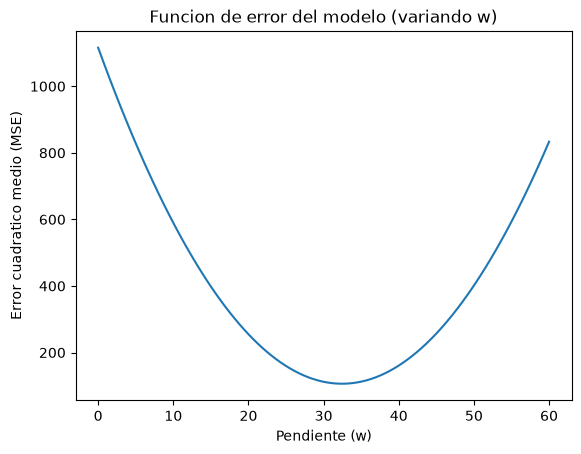

In [6]:
b_fijo = 137.1 #Establece un valor constante óptimo para el intercepto $b$.
valores_w = np.linspace(0, 60, 100) #Crea 100 puntos distribuidos uniformemente entre 0 y 60 para evaluar diferentes valores de la pendiente $w$.
errores = [] #Crea una lista vacía para guardar los valores de error calculados

for w in valores_w: #Bucle que itera sobre cada valor candidato de $w$. 
    prediccion = w * postulantes_norm + b_fijo #Genera las predicciones de la ecuación lineal
    mse = np.mean((prediccion - matriculados) ** 2) # Calcula el Error Cuadrático Medio
    errores.append(mse) #Añade el resultado del MSE a la lista de errores
    
plt.plot(valores_w, errores) #Dibuja la parábola curva del error en función de la pendiente $w$. 
plt.xlabel("Pendiente (w)") #Define el texto del eje X
plt.ylabel("Error cuadratico medio (MSE)") #Define el texto del eje Y
plt.title("Funcion de error del modelo (variando w)") #Establece el título del gráfico
plt.show() #Despliega la figura generada

## 4.4. Descenso de gradiente: cómo se entrena un modelo, paso a paso

In [8]:
w, b = 0.0, 0.0 # Inicializa los parámetros del modelo en $0.0$
tasa_aprendizaje = 0.3 # Asigna la hiperparámetro de tasa de aprendizaje $\alpha = 0.3$
n = len(postulantes_norm) # Obtiene la cantidad de datos n(n = 24)

for paso in range(1, 11): #Bucle que realiza 10 iteraciones del algoritmo
    prediccion = w * postulantes_norm + b #Estima los valores de la variable dependiente.
    error = prediccion - matriculados #Calcula la diferencia/residuo entre la estimación y el valor real
    mse = np.mean(error ** 2) #Obtiene el costo cuadrático medio de la iteración actual.
    
    gradiente_w = (2 / n) * np.sum(error * postulantes_norm) #Calcula la derivada parcial de la función de costo con respecto a w.
    gradiente_b = (2 / n) * np.sum(error) #Calcula la derivada parcial con respecto a b. 
    
    w = w - tasa_aprendizaje * gradiente_w #Actualiza la pendiente w dando un paso en sentido opuesto al gradiente
    b = b - tasa_aprendizaje * gradiente_b #Actualiza el intercepto b dando un paso en sentido opuesto al gradiente.
    
    print(f"Paso {paso}: MSE={mse:.2f} w={w} b={b}") #Muestra en consola la evolución del MSE, w y b paso a paso

Paso 1: MSE=19907.67 w=18.661836238544765 b=82.24999999999999
Paso 2: MSE=3295.39 w=26.593116639926293 b=115.14999999999999
Paso 3: MSE=620.37 w=29.96391081051344 b=128.31
Paso 4: MSE=189.29 w=31.39649833301298 b=133.574
Paso 5: MSE=119.76 w=32.00534803007528 b=135.6796
Paso 6: MSE=108.53 w=32.264109151326764 b=136.52184
Paso 7: MSE=106.72 w=32.37408262785864 b=136.858736
Paso 8: MSE=106.42 w=32.42082135538469 b=136.9934944
Paso 9: MSE=106.37 w=32.440685314583256 b=137.04739776
Paso 10: MSE=106.37 w=32.44912749724265 b=137.068959104


**Comprobación con Scikit-Learn:**

In [10]:
X_simple = postulantes_norm.values.reshape(-1, 1) #Convierte el vector en una matriz de 2 dimensiones requerida por Scikit-Learn
comprobacion = LinearRegression().fit(X_simple, matriculados) #Instancia y entrena el modelo de Regresión Lineal
w_sk = round(comprobacion.coef_[0], 2) # Obtiene el coeficiente de pendiente ajustado redondeado a 2 decimales
b_sk = round(comprobacion.intercept_, 2) # Obtiene el intercepto ajustado redondeado a 2 decimales
print("Scikit-learn: w =", w_sk, " b =", b_sk) # Muestra los coeficientes óptimos analíticos

Scikit-learn: w = 32.46  b = 137.08


## 4.5. Vista previa: el modelo completo

**Entrenamiento con múltiples variables:**

In [12]:
columnas = ["num_postulantes", "becas_otorgadas",
            "tasa_desercion_anterior", "campania_difusion"] #Lista con los nombres de las 4 variables independientes

X = matricula[columnas] # Matriz de características X
y = matricula["num_matriculados"] # Vector objetivo y

modelo = LinearRegression() # Crea el estimador de Regresión Lineal Múltiple
modelo.fit(X, y) # Ajusta los parámetros del modelo con las 4 variables simultáneamente.

print("Coeficientes:", dict(zip(X.columns, modelo.coef_.round(2)))) #  Muestra en un diccionario el coeficiente de peso Wi asignado a cada característica
print("Intercepto:", round(modelo.intercept_, 2)) # Imprime el sesgo global b
print("R2 sobre los datos de entrenamiento:", round(modelo.score(X, y), 3)) #Imprime el coeficiente de determinación R^2 (que evalúa qué porcentaje de la variación de la matrícula explica el modelo)

Coeficientes: {'num_postulantes': np.float64(0.49), 'becas_otorgadas': np.float64(1.38), 'tasa_desercion_anterior': np.float64(-328.52), 'campania_difusion': np.float64(6.67)}
Intercepto: 37.84
R2 sobre los datos de entrenamiento: 0.953


**Predicción para el semestre 2027-1:**

In [13]:
semestre_nuevo = pd.DataFrame([{
    "num_postulantes": 300,
    "becas_otorgadas": 30,
    "tasa_desercion_anterior": 0.09,
    "campania_difusion": 1,
}]) # Construye un DataFrame con una nueva observación no vista

prediccion = modelo.predict(semestre_nuevo) # Realiza la inferencia del número de estudiantes.
print("Matricula estimada 2027-I:", round(prediccion[0], 0), "estudiantes") 
# Imprime la predicción estimada redondeada al entero más cercano

Matricula estimada 2027-I: 204.0 estudiantes


**Gráfica de Evaluación (Real vs. Predicho):**

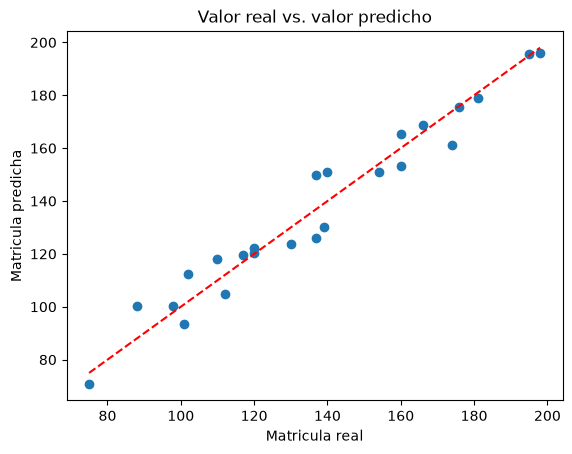

In [14]:
predicciones = modelo.predict(X) # Obtiene las estimaciones sobre todo el conjunto histórico
plt.scatter(y, predicciones) # Grafica los puntos en un plano cartesiano (Real vs. Predicho)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--") # Traza una línea roja punteada en la diagonal y=x (predicción ideal)
plt.xlabel("Matricula real") # Etiqueta del eje X
plt.ylabel("Matricula predicha") # Etiqueta del eje Y
plt.title("Valor real vs. valor predicho") # Título de la figura
plt.show() # Muestra la gráfica final

## 4.6. Clasificar casos: regresión, clasificación o clustering

**1. Predecir cuántos estudiantes se matricularán en un semestre futuro:**
Tipo de Aprendizaje: Supervisado.   
Tipo de Problema: Regresión.   
Justificación: El objetivo es predecir un valor numérico continuo (cantidad de alumnos).   

**2. Detectar si una transacción bancaria es fraudulenta o legítima, usando datos históricos etiquetados:**
Tipo de Aprendizaje: Supervisado.   
Tipo de Problema: Clasificación.   
Justificación: La salida a predecir es categórica y discreta (Fraudulenta / Legítima) y se cuenta con etiquetas previas.   

**3. Agrupar a los clientes de una tienda en línea según sus hábitos de compra, sin conocer categorías previas:**
Tipo de Aprendizaje: No Supervisado.   
Tipo de Problema: Clustering (Agrupamiento).   
Justificación: No existen etiquetas previa ni respuestas correctas; se busca descubrir patrones ocultos de agrupación.   

**4. Estimar cuántos milisegundos tardará un servidor en responder según su carga de CPU actual:**
Tipo de Aprendizaje: Supervisado.   
Tipo de Problema: Regresión.   
Justificación: La variable dependiente a estimar es una escala numérica continua (tiempo en ms).

## 5. Ejercicio Práctico de Laboratorio

### 5.1. Planteamiento del problema

Repetir, de forma independiente y con mayor profundidad, el mismo tipo de análisis aplicado en la Sección 4 (estadísticos descriptivos, correlación y descenso de gradiente) sobre un problema distinto: estimar el consumo eléctrico de un laboratorio de la universidad. Aquí, además, se comparará qué ocurre al usar distintas tasas de aprendizaje.

### 5.2. Parte A: Exploración y estadísticos descriptivos

In [15]:
consumo = pd.read_csv("consumo_laboratorios.csv") #Carga el dataset del consumo de laboratorios.

for columna in ["num_equipos", "consumo_kwh"]: # Bucle para recorrer ambas columnas numéricas
    c = consumo[columna] # Selecciona la serie de datos correspondiente.
    print(columna) # Muestra la cabecera de la columna
    print(" Media:", c.mean()) # Imprime el valor promedio
    print(" Mediana:", c.median()) # Imprime el punto medio
    print(" Moda:", c.mode().tolist()) # Imprime el valor con mayor frecuencia
    print(" Rango:", c.max() - c.min()) # Imprime la amplitud máxima de los datos
    print(" Varianza:", c.var()) # Imprime la dispersión cuadrática
    print(" Desviacion estandar:", c.std()) # Imprime la dispersión en unidades originales

num_equipos
 Media: 21.416666666666668
 Mediana: 24.5
 Moda: [15, 26]
 Rango: 32
 Varianza: 102.08333333333334
 Desviacion estandar: 10.103629710818451
consumo_kwh
 Media: 16.316666666666666
 Mediana: 17.1
 Moda: [17.1]
 Rango: 13.6
 Varianza: 20.33969696969697
 Desviacion estandar: 4.509955317926883


**Responder: ¿qué tan dispersos son el número de equipos y el consumo entre los 12 laboratorios registrados?**
Ambas variables están bastante dispersas entre los 12 laboratorios, ya que hay una diferencia muy grande entre el valor mínimo y el máximo, además de tener una desviación estándar alta. Por lo tanto, esto significa que los laboratorios no son para nada parecidos entre sí; mientras algunos tienen muy pocos equipos y gastan poquita energía, otros están súper cargados y consumen muchísimo más de la media.

### 5.3. Parte B: Correlación y selección justicada de variable

In [18]:
consumo.corr(numeric_only=True)["consumo_kwh"] #Evalúa la correlación lineal de todas las variables frente a consumo_kwh

num_equipos    0.569625
horas_uso      0.580143
consumo_kwh    1.000000
Name: consumo_kwh, dtype: float64

**Justificación de selección:** 
Se selecciona la variable que obtenga el coeficiente de correlación de Pearson más alto (cercano a 1.0). Tanto num_equipos como horas_uso son válidas si se argumenta adecuadamente su coeficiente numérico

### 5.4. Parte C: Descenso de gradiente parametrizado

In [19]:
variable = consumo["horas_uso"] #Asigna la variable explicativa seleccionada
variable_norm = (variable - variable.mean()) / variable.std() # Estandariza la variable explicativa a escala Z-score
consumo_kwh = consumo["consumo_kwh"].astype(float) # Establece la variable objetivo como tipo flotante

def descenso_gradiente(tasa_aprendizaje, pasos=10): # Define la función reutilizable para el cálculo
    w, b = 0.0, 0.0 # Inicialización de parámetros
    n = len(variable_norm) # Tamaño del conjunto de entrenamiento (n=12)
    for paso in range(1, pasos + 1): # Iteración sobre el número de pasos solicitados
        prediccion = w * variable_norm + b # Cálculo de la recta estimada
        error = prediccion - consumo_kwh # Diferencia entre estimación y valor real
        mse = np.mean(error ** 2) # Error cuadrático medio de la iteración

        gradiente_w = (2 / n) * np.sum(error * variable_norm) # Gradiente parcial respectivo a w
        gradiente_b = (2 / n) * np.sum(error) # Gradiente parcial respectivo a b
        
        w = w - tasa_aprendizaje * gradiente_w # Actualiza w usando el ratio asignado
        b = b - tasa_aprendizaje * gradiente_b # Actualiza b usando el ratio asignado
   
    return w, b, mse # Devuelve los parámetros finales calculados

w1, b1, mse1 = descenso_gradiente(tasa_aprendizaje=0.05) # Ejecución con alpha = 0.05
w2, b2, mse2 = descenso_gradiente(tasa_aprendizaje=1.2) # Ejecución con alpha = 1.2 

print("tasa=0.05: w =", w1, " b =", b1, " MSE final =", mse1) #Imprime la comparación entre ambas tasas de aprendizaje
print("tasa=1.2: w =", w2, " b =", b2, " MSE final =", mse2)

tasa=0.05: w = 1.61605095173763  b = 10.627396785701668  MSE final = 53.44161684657947
tasa=1.2: w = -13.583757842833784  b = -455.65051203583926  MSE final = 113828.93455548567


### 5.5. Parte D: Reflexión

**Tasa de aprendizaje pequeña (alpha = 0.05):**
Da pasos muy pequeños en la superficie de la función de error. Es muy estable y garantiza convergencia hacia el mínimo global del MSE, pero requiere una mayor cantidad de pasos o iteraciones para llegar a la solución óptima.   

**Tasa de aprendizaje grande (alpha = 1.2):**
El tamaño del paso sobrepasa el punto mínimo de la parábola (fenómeno llamado overshooting). Esto provoca que los parámetros oscilen salvajemente y el error (MSE) empiece a crecer o divergir hacia valores extremadamente grandes o infinitos (inf), alejándose por completo de la optimización